# Modelling

Train and evaluate models using outputs from preprocessing.ipynb.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipeline_out = Path('outputs/pipeline')
X_train = pd.read_csv(pipeline_out / 'X_train.csv')
X_test = pd.read_csv(pipeline_out / 'X_test.csv')
y_train = pd.read_csv(pipeline_out / 'y_train.csv')['Attrition']
y_test = pd.read_csv(pipeline_out / 'y_test.csv')['Attrition']

X = pd.concat([X_train, X_test], axis=0, ignore_index=True)

# Scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, C=0.1),
    'Random Forest': RandomForestClassifier(
        n_estimators=1000,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results.append({
        'model': name,
        'accuracy': round(accuracy_score(y_test, preds), 4),
        'precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'recall': round(recall_score(y_test, preds, zero_division=0), 4),
        'f1_score': round(f1_score(y_test, preds, zero_division=0), 4),
        'roc_auc': round(roc_auc_score(y_test, probs), 4),
    })

comparison_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)
out = Path('outputs')
out.mkdir(parents=True, exist_ok=True)
comparison_path = out / 'model_comparison.csv'
try:
    comparison_df.to_csv(comparison_path, index=False)
except PermissionError:
    fallback_path = out / 'model_comparison_latest.csv'
    comparison_df.to_csv(fallback_path, index=False)
    print(f'Could not write to {comparison_path}; saved to {fallback_path} instead.')
comparison_df


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.8810,0.7727,0.3617,0.4928,0.8045
1,Random Forest,0.8367,0.4615,0.1277,0.2000,0.8030
2,XGBoost,0.8673,0.7857,0.2340,0.3607,0.7890


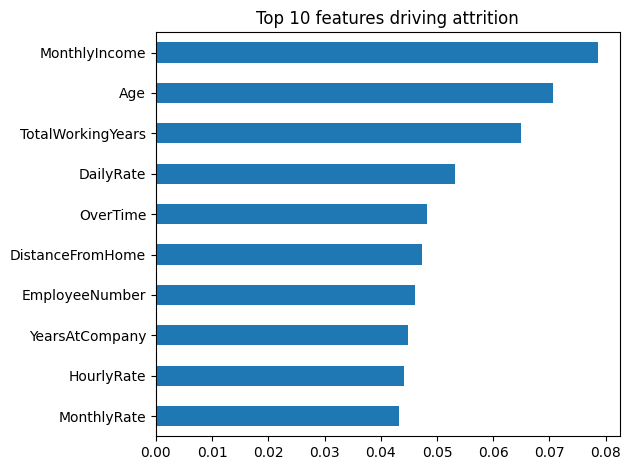

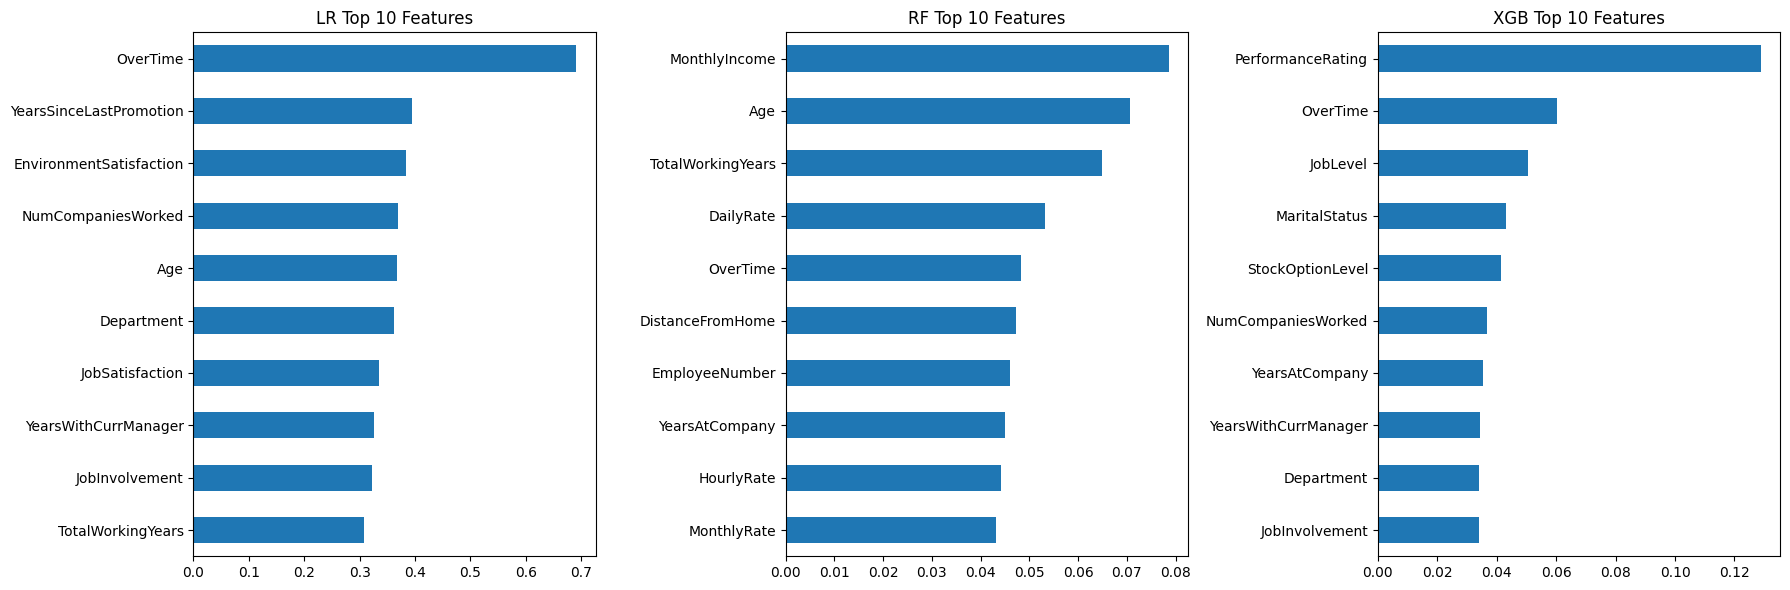

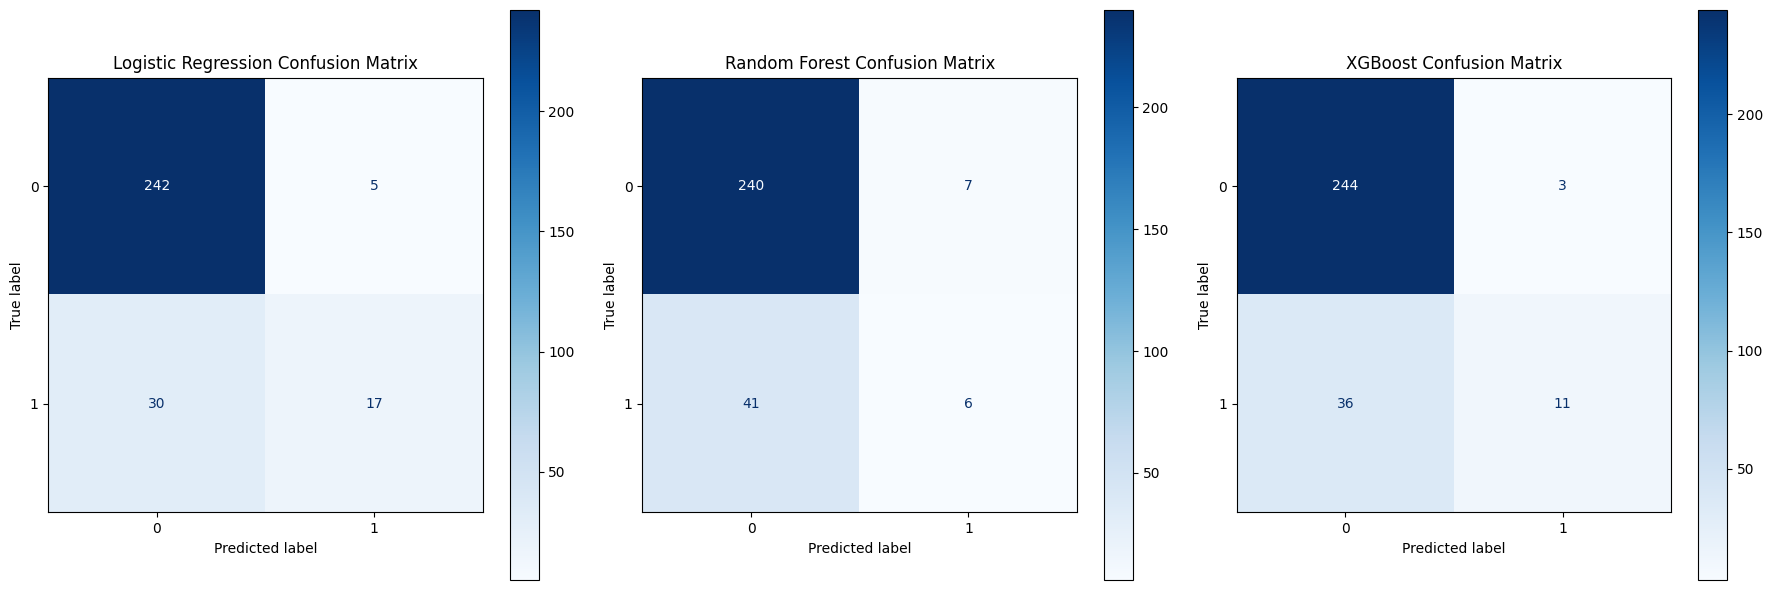

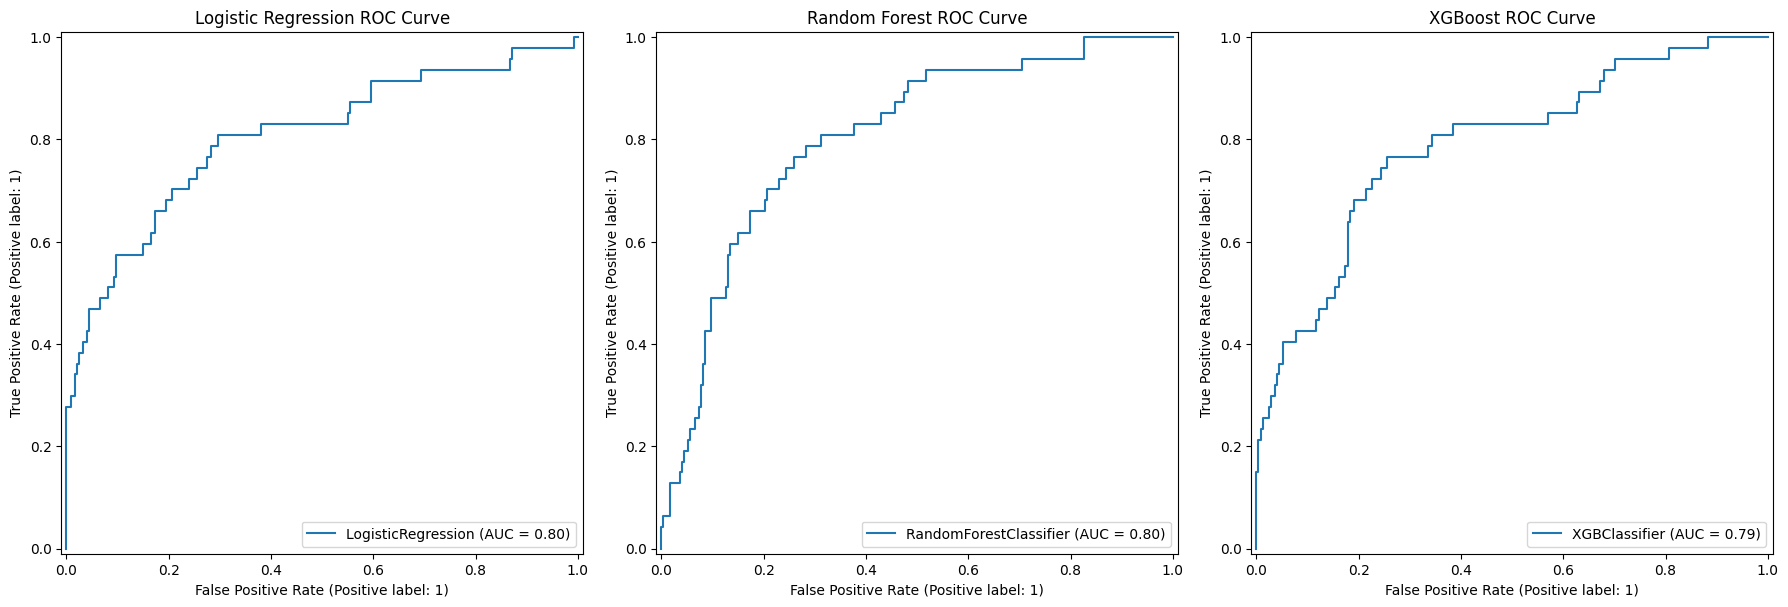

In [2]:
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

out = Path('outputs/figures')
out.mkdir(parents=True, exist_ok=True)

# 1. Feature importance
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).sort_values().plot(kind='barh', title='Top 10 features driving attrition')
plt.tight_layout()
plt.savefig(out / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 1. Feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Logistic Regression
lr = models['Logistic Regression']
feat_imp_lr = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
feat_imp_lr.nlargest(10).sort_values().plot(kind='barh', ax=axes[0], title='LR Top 10 Features')

# Random Forest
rf = models['Random Forest']
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp_rf.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], title='RF Top 10 Features')

# XGBoost
xgb = models['XGBoost']
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp_xgb.nlargest(10).sort_values().plot(kind='barh', ax=axes[2], title='XGB Top 10 Features')

plt.tight_layout()
plt.savefig(out / "feature_importance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Confusion matrices comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    if name == 'Logistic Regression':
        ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[i], cmap="Blues")
    else:
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[i], cmap="Blues")
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.savefig(out / "confusion_matrices_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. ROC curves comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (name, model) in enumerate(models.items()):
    if name == 'Logistic Regression':
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[i])
    else:
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[i])
    axes[i].set_title(f'{name} ROC Curve')

plt.tight_layout()
plt.savefig(out / "roc_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()